# 08 — Anomaly Analysis
رصد المعاملات غير المعتادة إحصائياً. النتائج Potentially Anomalous وليست Fraud Findings.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = Path('../data/processed')
OUT = Path('../visualizations/transactions')
OUT.mkdir(parents=True, exist_ok=True)
source = PROCESSED / 'cleaned_transactions.csv'
if not source.exists(): source = PROCESSED / 'final_dataset.csv'
if not source.exists(): raise FileNotFoundError('Run the cleaning notebook first.')
df = pd.read_csv(source)

def find(candidates, required=True):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None: raise KeyError(f'Expected one of {candidates}')
    return col

amount = find(['amount_usd', 'amount', 'transaction_amount', 'value'])
date = find(['transaction_date', 'date', 'created_at'])
customer = find(['customer_id', 'customerId', 'client_id'], required=False)
df[date] = pd.to_datetime(df[date], errors='coerce')
df = df[df[date].notna()].copy()

In [2]:
# Screening parameters (documented; tune on real data).
Z_THRESHOLD = 4.0   # robust z-score on log amount
MIN_GROUP = 30      # minimum history for a customer x category group
FREQ_K = 6          # MADs above the customer's typical daily count


In [3]:
# Transparent, robust screening rules (NOT a fraud detector).
# 1) Amount rule: robust z-score of log(amount_usd) inside each customer x category group (median/MAD),
#    so a normal rent or utility bill is compared with the customer's own history, not with the whole bank.
# 2) Frequency rule: customer-day transaction count far above that customer's own typical day.
# Recurring items (subscriptions, salary, transfers) are excluded from the amount rule.
work = df.copy()
work['_log_amt'] = np.log1p(work[amount])

def flag(col):
    return work[col].astype(str).str.lower().eq('true') if col in work.columns else pd.Series(False, index=work.index)

recurring = flag('is_subscription') | flag('is_salary') | flag('is_transfer')
keys = [k for k in [customer, 'category'] if k and k in work.columns]
if keys:
    grp = work.groupby(keys)['_log_amt']
    med = grp.transform('median')
    dev = work['_log_amt'] - med
    mad = dev.abs().groupby([work[k] for k in keys]).transform('median')
    size = grp.transform('size')
    work['amount_robust_z'] = (0.6745 * dev / mad.where(mad > 0)).fillna(0)
    work['amount_anomaly'] = (work['amount_robust_z'] > Z_THRESHOLD) & (size >= MIN_GROUP) & ~recurring
else:
    work['amount_robust_z'] = 0.0
    work['amount_anomaly'] = False

if customer:
    work['_day'] = work[date].dt.date
    daily = work.groupby([customer, '_day']).size().rename('customer_day_count').reset_index()
    work = work.merge(daily, on=[customer, '_day'], how='left')
    stats = daily.groupby(customer)['customer_day_count'].agg(['median', lambda s: (s - s.median()).abs().median()])
    stats.columns = ['cust_median', 'cust_mad']
    work = work.merge(stats, left_on=customer, right_index=True, how='left')
    freq_limit = work['cust_median'] + FREQ_K * work['cust_mad'].clip(lower=1)
    work['frequency_anomaly'] = work['customer_day_count'] > freq_limit
else:
    work['customer_day_count'] = pd.NA
    work['frequency_anomaly'] = False

work['potential_anomaly'] = work['amount_anomaly'] | work['frequency_anomaly']
work['anomaly_score'] = work['amount_robust_z'].clip(lower=0)
df = work
keep = [c for c in [ 'transaction_id', customer, 'account_id', date, 'amount', 'currency', amount, 'category', 'merchant_name', 'transaction_type', 'payment_channel', 'amount_robust_z', 'customer_day_count', 'amount_anomaly', 'frequency_anomaly', 'anomaly_score'] if c and c in df.columns]
keep = list(dict.fromkeys(keep))
anomalies = df.loc[df['potential_anomaly'], keep].sort_values('anomaly_score', ascending=False)
anomalies.to_csv(PROCESSED / 'potentially_anomalous_transactions.csv', index=False)
summary = pd.DataFrame([
    {'rule': f'amount_robust_z_gt_{Z_THRESHOLD}_customer_category', 'flagged_rows': int(df['amount_anomaly'].sum())},
    {'rule': f'customer_day_count_gt_median_plus_{FREQ_K}_mad', 'flagged_rows': int(df['frequency_anomaly'].sum())},
    {'rule': 'any_rule', 'flagged_rows': int(df['potential_anomaly'].sum())},
])
summary['share_pct'] = summary['flagged_rows'] / len(df) * 100
summary.to_csv(PROCESSED / 'anomaly_rule_summary.csv', index=False)
summary


,rule,flagged_rows,share_pct
0,amount_robust_z_gt_4.0_customer_category,3098,0.650564
1,customer_day_count_gt_median_plus_6_mad,6085,1.277819
2,any_rule,9148,1.921034


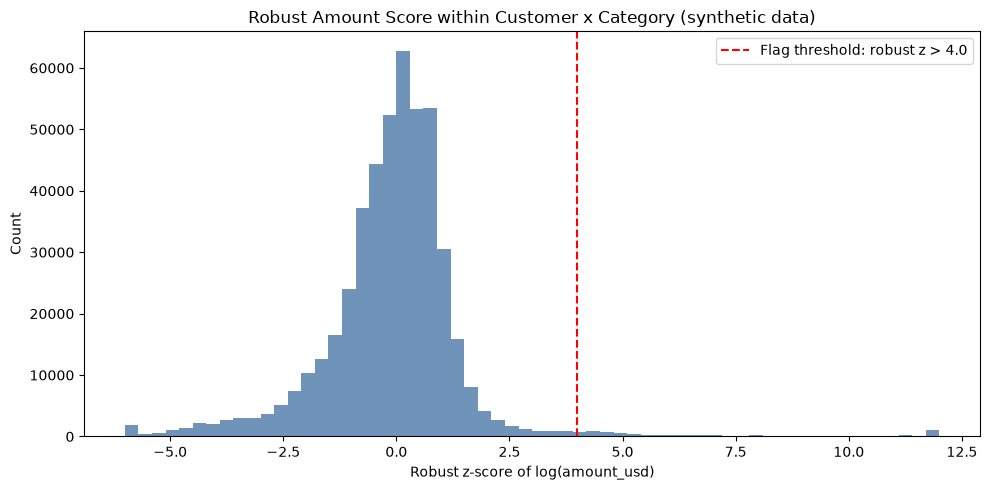

Potentially anomalous rows: 9148 of 476202 (1.92%)


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['amount_robust_z'].clip(-6, 12), bins=60, color='#4c78a8', alpha=.8)
ax.axvline(Z_THRESHOLD, color='red', linestyle='--', label=f'Flag threshold: robust z > {Z_THRESHOLD}')
ax.set_title('Robust Amount Score within Customer x Category (synthetic data)')
ax.set_xlabel('Robust z-score of log(amount_usd)')
ax.set_ylabel('Count')
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'potential_anomaly_amount_threshold.png', dpi=150)
plt.show()
plt.close(fig)
print(f'Potentially anomalous rows: {len(anomalies)} of {len(df)} ({len(anomalies)/len(df):.2%})')


## Review protocol
1. Inspect the flagged transaction and its customer/account context.
2. Check reversals, scheduled payments, holidays, and legitimate high-value events.
3. Record the investigation outcome separately.
4. Do not call a transaction fraudulent based on these statistical rules alone.